# 1. The data, and why a synthetic generator is the point

Reference-free action-quality assessment has a measurement problem: to check whether an explanation is *correct* you need to know what actually caused the quality loss, and no human-annotated dataset carries that.

This generator does. A degradation is a named, severity-parameterised edit to a joint-angle trajectory; the quality label is an explicit function of the applied severities; and the per-joint attribution ground truth is obtained by running forward kinematics twice, with and without each defect.

**The limitation, stated up front:** a synthetic label is not a human judge's rating. This validates the *mechanism*, not real-world agreement.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, torch
torch.set_num_threads(2)
pd.set_option("display.width", 200)
import matplotlib.pyplot as plt

# Notebooks run with cwd=notebooks/, so the figure and table roots have to be
# repointed at the repository's results/ tree. Without this every figure lands in
# notebooks/results/figures/ and the committed figures silently never update.
import saqa.viz as _viz, saqa.report as _report
_viz.FIGURES = ROOT / "results" / "figures"
_viz.TABLES = _report.TABLES = ROOT / "results" / "tables"
tables = _viz.TABLES
from saqa.data import build_dataset, GeneratorConfig, label_stats, ACTION_CLASSES, KIND_WEIGHTS
from saqa.data.generator import generate_sample
cfg = GeneratorConfig(num_frames=48)
data = build_dataset(300, cfg)
print(ACTION_CLASSES)
print(KIND_WEIGHTS)
pd.Series(label_stats(data)).round(4)

('squat', 'overhead_press', 'lunge', 'gait', 'throw')
{'rom': 0.4, 'asymmetry': 0.35, 'tempo': 0.25, 'jerk': 0.2, 'instability': 0.3, 'compensation': 0.45}


n             300.0000
mean            0.7167
sd              0.2027
min             0.0500
max             1.0000
frac_clean      0.1367
frac_floor      0.0033
dtype: float64

## Five kinematically distinct actions

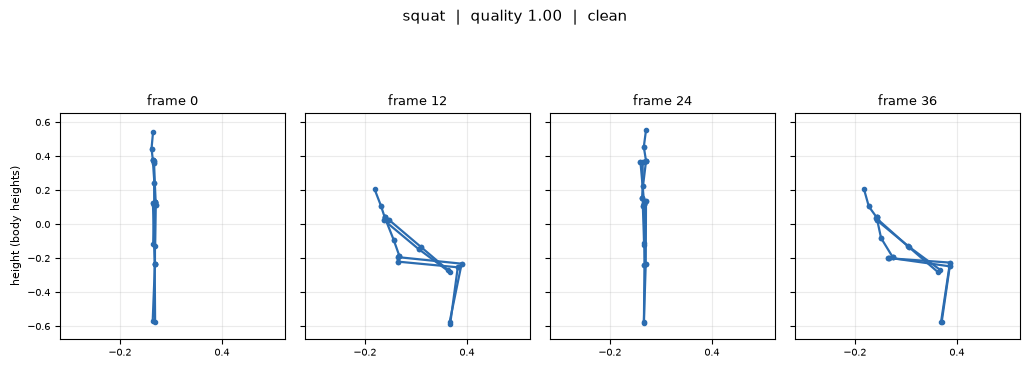

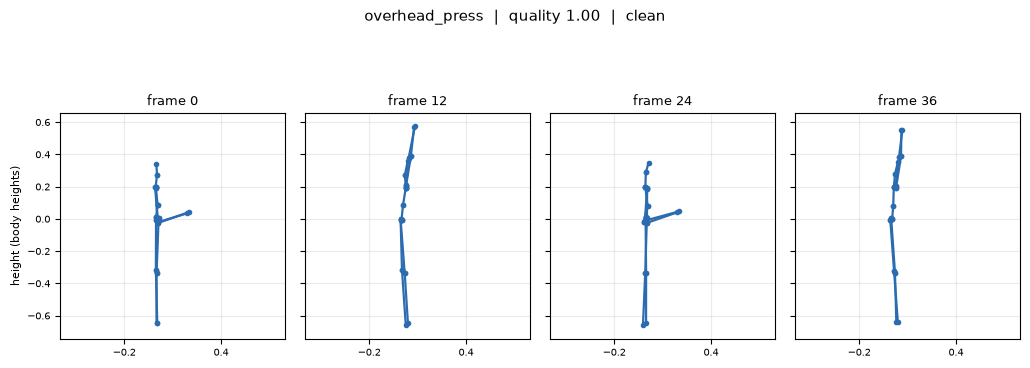

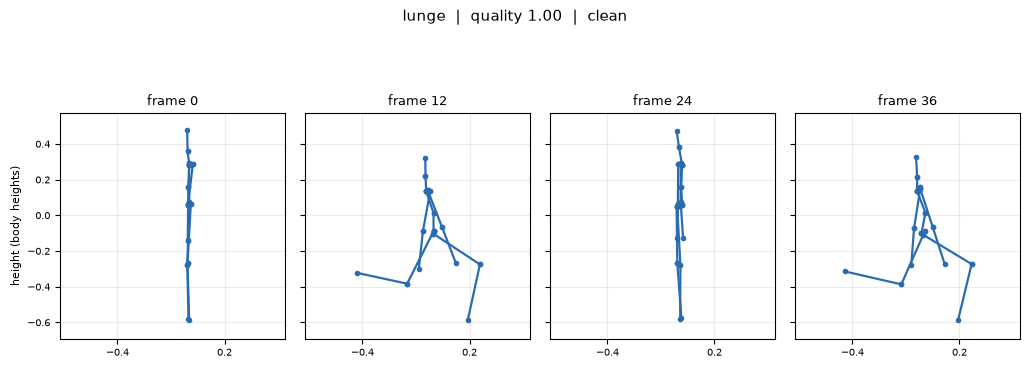

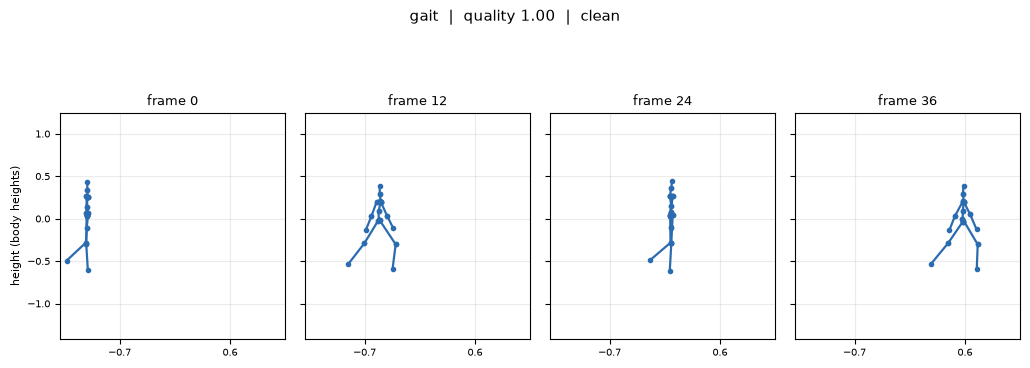

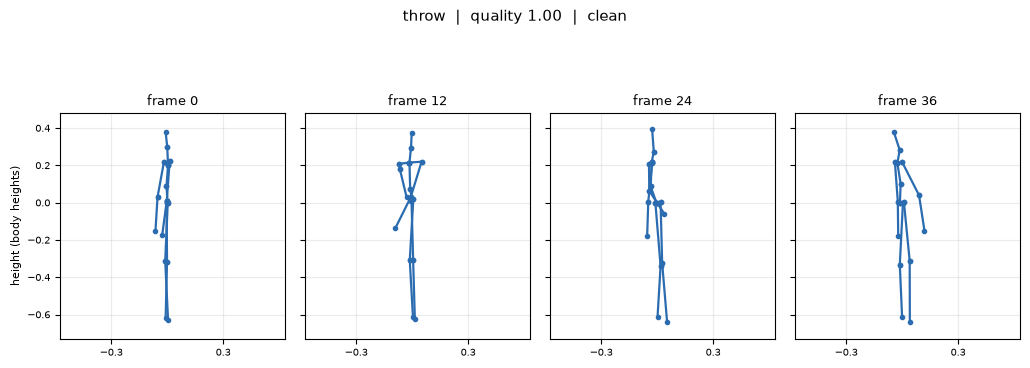

In [2]:
from saqa.viz import plot_skeleton_frames
for action in ACTION_CLASSES:
    s = next(x for x in (generate_sample(i, cfg) for i in range(300))
             if x.action == action and not x.degradations)
    plot_skeleton_frames(s, frames=(0, 12, 24, 36), name=f'nb_skeleton_{action}.png')
    plt.show()

## The label distribution

The ceiling at 1.0 is populated on purpose (clean executions exist) and the floor is clipped at 0.05 so the bottom decile does not pile up, which would make rank correlation look better than it is.

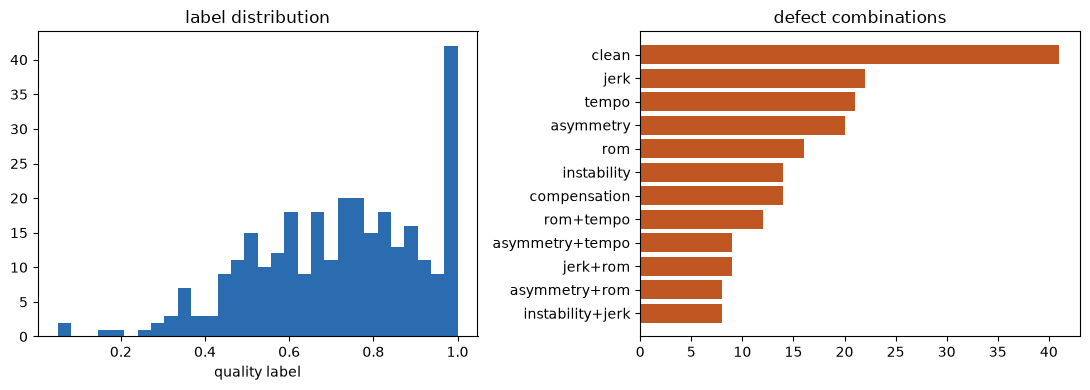

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(data.quality, bins=30, color='#2b6cb0')
ax[0].set_xlabel('quality label'); ax[0].set_title('label distribution')
counts = pd.Series(data.combinations).value_counts().head(12)
ax[1].barh(counts.index[::-1], counts.values[::-1], color='#c05621')
ax[1].set_title('defect combinations'); plt.tight_layout(); plt.show()

## Attribution ground truth is concentrated, not uniform

If the truth were near-uniform over joints, attribution precision would be uninformative. It is not: the top three joints carry far more than the 3/17 a uniform vector would give.

top-3 joint mass: mean 0.489 vs 0.176 if uniform


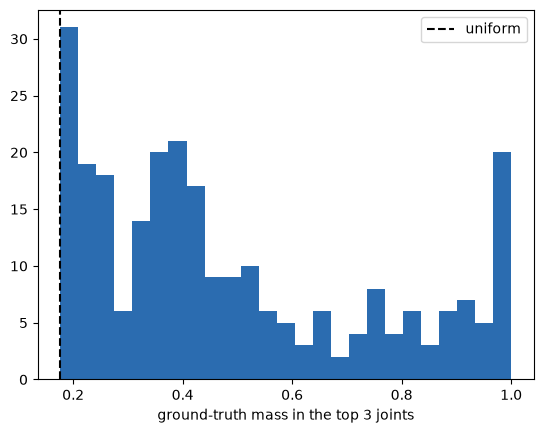

In [4]:
jt = data.joint_truth[data.joint_truth.sum(1) > 0]
top3 = np.sort(jt, axis=1)[:, -3:].sum(1)
print(f'top-3 joint mass: mean {top3.mean():.3f} vs {3/17:.3f} if uniform')
plt.hist(top3, bins=25, color='#2b6cb0')
plt.axvline(3/17, color='k', ls='--', label='uniform')
plt.xlabel('ground-truth mass in the top 3 joints'); plt.legend(); plt.show()

## The label is monotone in severity by construction

This is what makes the model-side monotonicity test meaningful: on a severity ladder, nothing varies but the defect.

In [5]:
from saqa.data import paired_degradation_sequences
lad = paired_degradation_sequences(6, GeneratorConfig(num_frames=48), seed=0)
for x in lad[:3]:
    print(f"{x['kind']:14s} {x['action']:16s} labels {np.round(x['quality'],3)}")

rom            throw            labels [1.  0.9 0.8 0.7 0.6]
asymmetry      overhead_press   labels [1.    0.912 0.825 0.738 0.65 ]
tempo          squat            labels [1.    0.938 0.875 0.812 0.75 ]
